## Index

0. [Colab setup](#0-colab-setup-no-op-when-running-locally)
[Overview](#train-and-test-gnn-link-existence-predictors)
1. [Hyperparameter tuning](#1-hyperparameter-tuning-grid-search)
    - [GraphSAGE tuning](#graphsage-tuning)
    - [SEAL tuning](#seal-tuning)
    - [MLP baseline tuning](#mlp-baseline-tuning)
2. [Train GraphSAGE](#2-train-graphsage)
3. [Train SEAL](#3-train-seal)
    - [Random-negative SEAL](#random-negative-seal)
    - [Hard-negative SEAL](#hard-negative-seal)
4. [Train MLP baselines](#4-train-mlp-baselines-no-graph-structure)
    - [Random-negative MLP baselines](#random-negative-mlp-baselines)
    - [Hard-negative MLP baselines](#hard-negative-mlp-baselines)
5. [Plot training curves](#5-plot-training-curves-from-the-logged-csvs)
6. [Compare hard negative results](#6-compare-hard-negative-results)
7. [Second hand citation analysis](#7-second-hand-citation-analysis)
8. [Conclusion](#8-conclusion)

> **NOTE**: on free colab this notebook will take more time than available. You need to save and re-run with multiple accounts (2-3 accounts according empirically to our experiments).

## 0. Colab setup (no-op when running locally)

Run this cell first **only if you're in Colab**. It is a no-op when the notebook runs locally, since the local environment is assumed to already have the repo and dependencies in place.

**In order it does:**
- Mounts Google Drive.
- On the first run, does a **sparse and partial clone** into Drive: only `scripts/`, `GNNs/`, and `graphs/cache/final_graphs.pkl` (about 3.4 GB total, compared to about 12 GB for the full repo). On later runs, it just `git pull`s instead of re-cloning.
- Copies the clone to Drive so weights and results persist across Colab sessions.
- Installs `torch-geometric`, `python-igraph`, `scikit-learn`, and `pandas` on top of Colab's pre-installed, CUDA-matched `torch` (left untouched).
- `cd`s into `GNNs/` so every `%run ../scripts/...` cell below resolves paths exactly as it would locally.

**Auth:** you'll be prompted once for a GitLab personal access token (needs `read_repository` scope, since the repo is private). The token is only kept in memory for the clone. It is never written to disk or to this notebook.

In [ ]:
import sys
import os
import subprocess
import shutil

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

if "google.colab" in sys.modules:
    from google.colab import drive
    try:
        drive.mount("/content/drive")
    except ValueError:
        drive.mount("/content/drive", force_remount=True)

    LOCAL_DIR = "/content/pellegrinoscavello2425"
    DRIVE_DIR = "/content/drive/MyDrive/pellegrinoscavello2425"
    REPO_URL = "https://dvcs.apice.unibo.it/pika-lab/courses/ai-ethics/projects/pellegrinoscavello2425"
    BRANCH = "master"

    if not os.path.isdir(os.path.join(LOCAL_DIR, ".git")):
        from getpass import getpass
        token = getpass("GitLab personal access token (used once for this clone, not stored): ")
        auth_url = REPO_URL.replace("https://", f"https://oauth2:{token}@")

        print("Cloning to local disk (sparse + partial: scripts/, GNNs/, and just "
              "final_graphs.pkl from graphs/cache/, ~3.4GB total, not the full ~12GB)...")
        subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout",
                         auth_url, LOCAL_DIR], check=True)
        subprocess.run(["git", "sparse-checkout", "init", "--no-cone"], check=True, cwd=LOCAL_DIR)
        with open(os.path.join(LOCAL_DIR, ".git", "info", "sparse-checkout"), "w") as f:
            f.write("/scripts/\n/GNNs/\n/graphs/cache/final_graphs.pkl\n")

        print("Downloading final_graphs.pkl (~3.4GB) -- this can take a while, output streams live below:")
        proc = subprocess.Popen(["git", "checkout", BRANCH], cwd=LOCAL_DIR,
                                 stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in proc.stdout:
            print(" ", line.rstrip())
        proc.wait()
        if proc.returncode != 0:
            raise subprocess.CalledProcessError(proc.returncode, "git checkout")
    else:
        print("Local clone already present -- pulling latest changes instead of re-cloning...")
        subprocess.run(["git", "-C", LOCAL_DIR, "pull"], check=True)

    # Push the finished result to Drive as one plain copy so results
    # persist across sessions, instead of writing through FUSE the whole
    # way. Skipped if Drive already has an up-to-date copy, so re-running
    # this cell mid-session doesn't re-copy 3.4GB for nothing.
    drive_pkl = os.path.join(DRIVE_DIR, "graphs", "cache", "final_graphs.pkl")
    local_pkl = os.path.join(LOCAL_DIR, "graphs", "cache", "final_graphs.pkl")
    needs_copy = (
        not os.path.isdir(DRIVE_DIR)
        or not os.path.exists(drive_pkl)
        or os.path.getsize(drive_pkl) != os.path.getsize(local_pkl)
    )
    if needs_copy:
        print("Copying scripts/, GNNs/, and final_graphs.pkl to Drive (persists across sessions)...")
        for name in ("scripts", "GNNs"):
            dst = os.path.join(DRIVE_DIR, name)
            if os.path.isdir(dst):
                shutil.rmtree(dst)
            shutil.copytree(os.path.join(LOCAL_DIR, name), dst)
        os.makedirs(os.path.dirname(drive_pkl), exist_ok=True)
        shutil.copy2(local_pkl, drive_pkl)
        print("Copy to Drive done.")
    else:
        print("Drive copy already up to date -- skipping copy.")

    print("Installing Python deps on top of Colab's pre-installed torch (leaving it alone so its CUDA build stays intact)...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                     "torch-geometric==2.8.0", "python-igraph", "scikit-learn", "pandas"], check=True)

    # Training runs out of the Drive copy of GNNs/ so weights/ and results/
    # written during training land on Drive directly and persist normally.
    os.chdir(os.path.join(DRIVE_DIR, "GNNs"))
    print("Working directory:", os.getcwd())

    import torch
    print(f"torch {torch.__version__} -- CUDA available: {torch.cuda.is_available()}")
    print("\nSetup done. Run the rest of this notebook's cells normally from here.")
else:
    print("Not running in Colab -- skipping Drive mount / clone / install (local env assumed ready).")

Mounted at /content/drive
GitLab personal access token (used once for this clone, not stored): ··········
Cloning to local disk (sparse + partial: scripts/, GNNs/, and just final_graphs.pkl from graphs/cache/, ~3.4GB total, not the full ~12GB)...
  Already on 'master'
  Your branch is up to date with 'origin/master'.
Copying scripts/, GNNs/, and final_graphs.pkl to Drive (persists across sessions)...
Copy to Drive done.
Installing Python deps on top of Colab's pre-installed torch (leaving it alone so its CUDA build stays intact)...
Working directory: /content/drive/MyDrive/pellegrinoscavello2425/GNNs
torch 2.11.0+cu128 -- CUDA available: True

Setup done. Run the rest of this notebook's cells normally from here.


# Train and Test GNN Link Existence Predictors

The pipeline is GraphSAGE and SEAL on top of the SPECTER2 node embeddings already attached to every node in `graphs/cache/final_graphs.pkl`, plus MLP baselines and a second-hand citation analysis (`scripts/second_hand_citation.py`) at the end.

**Shared conventions across `train_graphsage.py` and `train_seal.py`:**
- Both print `[phase] ...` progress lines with elapsed time for each major step (loading graphs, building the dataset and split, training, held-out evaluation).
- Both **skip training entirely** if `--out` already points at an existing checkpoint. They load it and jump straight to validation and test evaluation instead. Delete the checkpoint under `../GNNs/weights/` to force a retrain.
- Both log:
  - per-epoch metrics (loss, dev AUC and AP, elapsed time) to `../GNNs/results/{model}_epoch_metrics.csv`
  - final train, dev, and test AUC and AP to `../GNNs/results/{model}_eval_metrics.csv`
  
  Both files are meant to be read back in for plotting in sections 5 and 6.

> **Note on this run:** several cells below (GraphSAGE and SEAL random-negative training, in particular) found an existing checkpoint and skipped training, reporting metrics from a previous run rather than a fresh fit. That is flagged inline where it happens.

## 1. Hyperparameter tuning (grid search)

Grid search over each script's hyperparameter grid via `scripts/tune_hyperparams.py` (see its docstring). Run this **before** the fitting cells in sections 2 to 4, so the best combination found here can be typed into their `--hidden-dim`, `--lr`, `--weight-decay`, `--label-dim` flags.

**How it works:**
- Each trial is a clean subprocess run of the corresponding `train_*.py` script, model-selected on `dev`, identical protocol to the fitting cells below.
- Tuning trials reuse the same `--epochs`, `--patience`, `--val-metric`, `--min-delta` early-stopping settings as the final fit, so tuning and the final fit are on equal footing.
- Only the **best** trial's checkpoint is kept, written under `../GNNs/weights/tuning/<script>/`.
- A ranked summary is written to `../GNNs/results/<script>_tuning_results.csv`.
- Flags: `--dry-run` to preview the grid without training, `--param name=v1,v2,...` to override a default grid value.

**The grids below are informed by the source papers, not just built-in defaults:**

- **GraphSAGE**, Hamilton, Ying & Leskovec, [*Inductive Representation Learning on Large Graphs*, NeurIPS 2017](https://arxiv.org/abs/1706.02216).
  - The 2-layer encoder is the paper's own recommendation and is kept fixed, not swept (deeper GNNs oversmooth), though the grid below also sweeps `num-layers=2,3` to check that assumption empirically.
  - `hidden-dim` in {128, 256}, the paper's own Reddit and PPI range.
  - `lr` in {1e-2, 1e-3, 1e-4}, spanning the range explored in the paper's appendix.
  - `weight-decay` in {5e-4, 0}. 5e-4 is the GCN convention default (Kipf & Welling, [ICLR 2017](https://arxiv.org/abs/1609.02907)), widely reused for GNN link prediction.
- **SEAL**, Zhang & Chen, [*Link Prediction Based on Graph Neural Networks*, NeurIPS 2018](https://arxiv.org/abs/1802.09691) ([official code](https://github.com/muhanzhang/SEAL)).
  - `hidden-dim` in {32, 64}, paper and official default is 32.
  - `lr` in {1e-4, 1e-3}, bracketing the official implementation's 1e-4.
  - `label-dim` (the learned DRNL label-embedding size) is **not** a paper parameter. It is this repo's own addition on top of the paper's raw one-hot DRNL labeling, so it is held fixed at the script's default (16) rather than swept without literature grounding.
- **Hard-negative variants** (`graphsage_hard`, `seal_hard`) reuse their base encoder's grid unchanged. The BPR ranking loss they add (Rendle, Freudenthaler, Gantner & Schmidt-Thieme, [*BPR: Bayesian Personalized Ranking from Implicit Feedback*, UAI 2009](https://arxiv.org/abs/1205.2618)) changes the training objective, not the encoder architecture, so the same encoder hyperparameter ranges apply.

> **Note:** SEAL's per-trial cost includes re-extracting enclosing subgraphs from scratch, the slow step logged in section 3. Since each trial is an independent subprocess, the `seal` and `seal_hard` grids below are kept small (4 trials each) for that reason.

### GraphSAGE tuning

In [ ]:
%run ../scripts/tune_hyperparams.py --script graphsage \
    --param lr=1e-2,1e-3,1e-4 \
    --param hidden-dim=128,256 \
    --param weight-decay=5e-4,0 \
    --param num-layers=2,3 \
    --epochs 50 \
    --patience 4 \
    --min-delta 0 \
    --val-metric ap


Grid for --script graphsage: lr=['1e-2', '1e-3', '1e-4'], hidden-dim=['128', '256'], weight-decay=['5e-4', '0'], num-layers=['2', '3']
24 trial(s) total
[1/24] lr=1e-2, hidden-dim=128, weight-decay=5e-4, num-layers=2
  dev_ap=0.9800  (75.1s)
[2/24] lr=1e-2, hidden-dim=128, weight-decay=5e-4, num-layers=3
  dev_ap=0.9828  (71.9s)
[3/24] lr=1e-2, hidden-dim=128, weight-decay=0, num-layers=2
  dev_ap=0.9753  (71.1s)
[4/24] lr=1e-2, hidden-dim=128, weight-decay=0, num-layers=3
  dev_ap=0.9835  (71.3s)
[5/24] lr=1e-2, hidden-dim=256, weight-decay=5e-4, num-layers=2
  dev_ap=0.9698  (78.0s)
[6/24] lr=1e-2, hidden-dim=256, weight-decay=5e-4, num-layers=3
  dev_ap=0.9825  (82.5s)
[7/24] lr=1e-2, hidden-dim=256, weight-decay=0, num-layers=2
  dev_ap=0.9702  (75.1s)
[8/24] lr=1e-2, hidden-dim=256, weight-decay=0, num-layers=3
  dev_ap=0.9545  (76.3s)
[9/24] lr=1e-3, hidden-dim=128, weight-decay=5e-4, num-layers=2
  dev_ap=0.9808  (71.8s)
[10/24] lr=1e-3, hidden-dim=128, weight-decay=5e-4, num-la

In [ ]:
%run ../scripts/tune_hyperparams.py --script graphsage_hard \
    --param lr=1e-2,1e-3,1e-4 \
    --param hidden-dim=128,256 \
    --param weight-decay=5e-4,0 \
    --param num-layers=2,3 \
    --epochs 50 \
    --patience 4 \
    --min-delta 0 \
    --val-metric ap


Grid for --script graphsage_hard: lr=['1e-2', '1e-3', '1e-4'], hidden-dim=['128', '256'], weight-decay=['5e-4', '0'], num-layers=['2', '3']
24 trial(s) total
[1/24] lr=1e-2, hidden-dim=128, weight-decay=5e-4, num-layers=2
  dev_ap=0.8672  (87.5s)
[2/24] lr=1e-2, hidden-dim=128, weight-decay=5e-4, num-layers=3
  dev_ap=0.8678  (95.4s)
[3/24] lr=1e-2, hidden-dim=128, weight-decay=0, num-layers=2
  dev_ap=0.8661  (85.5s)
[4/24] lr=1e-2, hidden-dim=128, weight-decay=0, num-layers=3
  dev_ap=0.8653  (90.9s)
[5/24] lr=1e-2, hidden-dim=256, weight-decay=5e-4, num-layers=2
  dev_ap=0.8210  (93.5s)
[6/24] lr=1e-2, hidden-dim=256, weight-decay=5e-4, num-layers=3
  dev_ap=0.8580  (93.9s)
[7/24] lr=1e-2, hidden-dim=256, weight-decay=0, num-layers=2
  dev_ap=0.8636  (96.9s)
[8/24] lr=1e-2, hidden-dim=256, weight-decay=0, num-layers=3
  dev_ap=0.8624  (96.0s)
[9/24] lr=1e-3, hidden-dim=128, weight-decay=5e-4, num-layers=2
  dev_ap=0.8674  (97.4s)
[10/24] lr=1e-3, hidden-dim=128, weight-decay=5e-4, n

### SEAL tuning

In [ ]:
%run ../scripts/tune_hyperparams.py --script seal \
    --param lr=1e-4,1e-3 \
    --param hidden-dim=32,64 \
    --epochs 20 \
    --patience 4 \
    --val-metric ap


Grid for --script seal: lr=['1e-4', '1e-3'], hidden-dim=['32', '64'], label-dim=['16', '32']
8 trial(s) total
[1/8] lr=1e-4, hidden-dim=32, label-dim=16
  dev_ap=0.9894  (262.6s)
[2/8] lr=1e-4, hidden-dim=32, label-dim=32
  dev_ap=0.9852  (262.0s)
[3/8] lr=1e-4, hidden-dim=64, label-dim=16
  dev_ap=0.9890  (263.1s)
[4/8] lr=1e-4, hidden-dim=64, label-dim=32
  dev_ap=0.9904  (78.4s)
[5/8] lr=1e-3, hidden-dim=32, label-dim=16
  dev_ap=0.9854  (419.0s)
[6/8] lr=1e-3, hidden-dim=32, label-dim=32
  dev_ap=0.9894  (540.0s)
[7/8] lr=1e-3, hidden-dim=64, label-dim=16
  dev_ap=0.9871  (261.2s)
[8/8] lr=1e-3, hidden-dim=64, label-dim=32
  dev_ap=0.9845  (261.0s)

Tuning results written to /content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/results/seal_tuning_results.csv

Ranked results (8/8 trials succeeded):
  #1  dev_ap=0.9904  lr=1e-4, hidden-dim=64, label-dim=32  (/content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/weights/tuning/seal/trial_003.pt)
  #2  dev_ap=0.9894  l

In [ ]:
%run ../scripts/tune_hyperparams.py --script seal_hard \
    --param lr=1e-4,1e-3 \
    --param hidden-dim=32,64 \
    --epochs 20 \
    --patience 4 \
    --val-metric ap


Grid for --script seal_hard: lr=['1e-4', '1e-3'], hidden-dim=['32', '64'], label-dim=['16', '32']
8 trial(s) total
[1/8] lr=1e-4, hidden-dim=32, label-dim=16
  dev_ap=0.8334  (1660.3s)
[2/8] lr=1e-4, hidden-dim=32, label-dim=32
  dev_ap=0.8052  (1638.4s)
[3/8] lr=1e-4, hidden-dim=64, label-dim=16
  dev_ap=0.7923  (1641.5s)
[4/8] lr=1e-4, hidden-dim=64, label-dim=32
  dev_ap=0.8003  (1568.6s)
[5/8] lr=1e-3, hidden-dim=32, label-dim=16
  dev_ap=0.8646  (555.8s)
[6/8] lr=1e-3, hidden-dim=32, label-dim=32
  dev_ap=0.8265  (556.7s)
[7/8] lr=1e-3, hidden-dim=64, label-dim=16
  dev_ap=0.8716  (722.8s)
[8/8] lr=1e-3, hidden-dim=64, label-dim=32
  dev_ap=0.8259  (858.7s)

Tuning results written to /content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/results/seal_hard_tuning_results.csv

Ranked results (8/8 trials succeeded):
  #1  dev_ap=0.8716  lr=1e-3, hidden-dim=64, label-dim=16  (/content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/weights/tuning/seal_hard/trial_006.pt)
  

### Graph-free baselines (`mlp_baseline_common.py`)

Same node features, splits, decoder shape, and eval protocol as GraphSAGE above, but **no message passing**:

- **`mlp_raw`** scores pairs directly from the raw SPECTER2 and structural features. Only the decoder is learned.
- **`mlp_encoded`** adds a per-node MLP encoder with the same depth and width knobs as `SAGEEncoder`, but without `SAGEConv`. Each node is transformed independently of its neighbours.

These are the reference points that isolate what GraphSAGE's neighbourhood aggregation actually contributes on top of the paper's own features. Tuned here on the same grid shape as GraphSAGE for a fair comparison.

The two cells after `mlp_encoded` below tune the hard-negative counterparts, `mlp_raw_hard` and `mlp_encoded_hard` (`mlp_baseline_hard_common.py`), the same way. Hard 2-hop negatives plus a BPR ranking loss, mirroring `graphsage_hard` and `seal_hard`.

### MLP baseline tuning

In [2]:
%run ../scripts/tune_hyperparams.py --script mlp_raw \
    --param lr=1e-2,1e-3,1e-4 \
    --param hidden-dim=64,128,256 \
    --param weight-decay=5e-4,0 \
    --epochs 50 \
    --patience 4 \
    --min-delta 0 \
    --val-metric ap \
    --decoder-batch-size 16384

Grid for --script mlp_raw: lr=['1e-2', '1e-3', '1e-4'], hidden-dim=['64', '128', '256'], weight-decay=['5e-4', '0']
18 trial(s) total
[1/18] lr=1e-2, hidden-dim=64, weight-decay=5e-4
  dev_ap=0.8477  (89.6s)
[2/18] lr=1e-2, hidden-dim=64, weight-decay=0
  dev_ap=0.8450  (75.7s)
[3/18] lr=1e-2, hidden-dim=128, weight-decay=5e-4
  dev_ap=0.9270  (72.5s)
[4/18] lr=1e-2, hidden-dim=128, weight-decay=0
  dev_ap=0.8326  (69.9s)
[5/18] lr=1e-2, hidden-dim=256, weight-decay=5e-4
  dev_ap=0.9449  (73.1s)
[6/18] lr=1e-2, hidden-dim=256, weight-decay=0
  dev_ap=0.9483  (81.0s)
[7/18] lr=1e-3, hidden-dim=64, weight-decay=5e-4
  dev_ap=0.9031  (71.7s)
[8/18] lr=1e-3, hidden-dim=64, weight-decay=0
  dev_ap=0.9066  (72.1s)
[9/18] lr=1e-3, hidden-dim=128, weight-decay=5e-4
  dev_ap=0.9107  (95.3s)
[10/18] lr=1e-3, hidden-dim=128, weight-decay=0
  dev_ap=0.9229  (82.3s)
[11/18] lr=1e-3, hidden-dim=256, weight-decay=5e-4
  dev_ap=0.9551  (66.3s)
[12/18] lr=1e-3, hidden-dim=256, weight-decay=0
  dev_ap=0

In [ ]:
%run ../scripts/tune_hyperparams.py --script mlp_encoded \
    --param lr=1e-2,1e-3,1e-4 \
    --param hidden-dim=64,128,256 \
    --param weight-decay=5e-4,0 \
    --param num-layers=2,3 \
    --epochs 50 \
    --patience 4 \
    --min-delta 0 \
    --val-metric ap


Grid for --script mlp_encoded: lr=['1e-2', '1e-3', '1e-4'], hidden-dim=['64', '128', '256'], weight-decay=['5e-4', '0'], num-layers=['2', '3']
36 trial(s) total
[1/36] lr=1e-2, hidden-dim=64, weight-decay=5e-4, num-layers=2
  dev_ap=0.8570  (66.0s)
[2/36] lr=1e-2, hidden-dim=64, weight-decay=5e-4, num-layers=3
  dev_ap=0.9866  (77.2s)
[3/36] lr=1e-2, hidden-dim=64, weight-decay=0, num-layers=2
  dev_ap=0.8697  (66.4s)
[4/36] lr=1e-2, hidden-dim=64, weight-decay=0, num-layers=3
  dev_ap=0.8281  (65.8s)
[5/36] lr=1e-2, hidden-dim=128, weight-decay=5e-4, num-layers=2
  dev_ap=0.7722  (67.1s)
[6/36] lr=1e-2, hidden-dim=128, weight-decay=5e-4, num-layers=3
  dev_ap=0.9064  (66.8s)
[7/36] lr=1e-2, hidden-dim=128, weight-decay=0, num-layers=2
  dev_ap=0.7314  (66.8s)
[8/36] lr=1e-2, hidden-dim=128, weight-decay=0, num-layers=3
  dev_ap=0.9114  (67.7s)
[9/36] lr=1e-2, hidden-dim=256, weight-decay=5e-4, num-layers=2
  dev_ap=0.9328  (68.8s)
[10/36] lr=1e-2, hidden-dim=256, weight-decay=5e-4, nu

In [ ]:
%run ../scripts/tune_hyperparams.py --script mlp_raw_hard \
    --param lr=1e-2,1e-3,1e-4 \
    --param hidden-dim=64,128,256 \
    --param weight-decay=5e-4,0 \
    --epochs 50 \
    --patience 4 \
    --min-delta 0 \
    --val-metric ap


Grid for --script mlp_raw_hard: lr=['1e-2', '1e-3', '1e-4'], hidden-dim=['64', '128', '256'], weight-decay=['5e-4', '0']
18 trial(s) total
[1/18] lr=1e-2, hidden-dim=64, weight-decay=5e-4
  dev_ap=0.7055  (83.2s)
[2/18] lr=1e-2, hidden-dim=64, weight-decay=0
  dev_ap=0.7073  (83.3s)
[3/18] lr=1e-2, hidden-dim=128, weight-decay=5e-4
  dev_ap=0.7289  (84.5s)
[4/18] lr=1e-2, hidden-dim=128, weight-decay=0
  dev_ap=0.7283  (85.3s)
[5/18] lr=1e-2, hidden-dim=256, weight-decay=5e-4
  dev_ap=0.8758  (136.3s)
[6/18] lr=1e-2, hidden-dim=256, weight-decay=0
  dev_ap=0.8690  (146.9s)
[7/18] lr=1e-3, hidden-dim=64, weight-decay=5e-4
  dev_ap=0.8396  (133.8s)
[8/18] lr=1e-3, hidden-dim=64, weight-decay=0
  dev_ap=0.8341  (135.4s)
[9/18] lr=1e-3, hidden-dim=128, weight-decay=5e-4
  dev_ap=0.8502  (138.3s)
[10/18] lr=1e-3, hidden-dim=128, weight-decay=0
  dev_ap=0.8478  (137.6s)
[11/18] lr=1e-3, hidden-dim=256, weight-decay=5e-4
  dev_ap=0.7578  (85.3s)
[12/18] lr=1e-3, hidden-dim=256, weight-decay=0

In [ ]:
%run ../scripts/tune_hyperparams.py --script mlp_encoded_hard \
    --param lr=1e-2,1e-3,1e-4 \
    --param hidden-dim=64,128,256 \
    --param weight-decay=5e-4,0 \
    --param num-layers=2,3 \
    --epochs 50 \
    --patience 4 \
    --min-delta 0 \
    --val-metric ap


Grid for --script mlp_encoded_hard: lr=['1e-2', '1e-3', '1e-4'], hidden-dim=['64', '128', '256'], weight-decay=['5e-4', '0'], num-layers=['2', '3']
36 trial(s) total
[1/36] lr=1e-2, hidden-dim=64, weight-decay=5e-4, num-layers=2
  dev_ap=0.8647  (111.0s)
[2/36] lr=1e-2, hidden-dim=64, weight-decay=5e-4, num-layers=3
  dev_ap=0.8339  (93.8s)
[3/36] lr=1e-2, hidden-dim=64, weight-decay=0, num-layers=2
  dev_ap=0.8525  (95.8s)
[4/36] lr=1e-2, hidden-dim=64, weight-decay=0, num-layers=3
  dev_ap=0.8548  (94.4s)
[5/36] lr=1e-2, hidden-dim=128, weight-decay=5e-4, num-layers=2
  dev_ap=0.8584  (106.5s)
[6/36] lr=1e-2, hidden-dim=128, weight-decay=5e-4, num-layers=3
  dev_ap=0.8631  (105.1s)
[7/36] lr=1e-2, hidden-dim=128, weight-decay=0, num-layers=2
  dev_ap=0.8486  (92.3s)
[8/36] lr=1e-2, hidden-dim=128, weight-decay=0, num-layers=3
  dev_ap=0.7684  (81.8s)
[9/36] lr=1e-2, hidden-dim=256, weight-decay=5e-4, num-layers=2
  dev_ap=0.8499  (101.2s)
[10/36] lr=1e-2, hidden-dim=256, weight-decay

## 2. Train GraphSAGE

Full-batch message passing over the observed edges of each split. Random-negative version first, then the hard-negative version with the BPR ranking loss.

In [ ]:
%run ../scripts/train_graphsage.py --epochs 50 \
    --hidden-dim 256 \
    --num-layers 2 \
    --lr 1e-3 \
    --weight-decay 5e-4 \
    --val-metric ap \
    --patience 4 \
    --min-delta 0 \
    --decoder-batch-size 16384 \
    --out ../GNNs/weights/graphsage_link_predictor_es_ap_final.pt


[phase] loading split graphs (train/dev/test)... (seed=0)
[phase] loading split graphs (29.0s)
[phase] building PyG data + RandomLinkSplit...
[phase] building PyG data + RandomLinkSplit (19.4s)
[phase] ../GNNs/weights/graphsage_link_predictor_es_ap_final.pt already exists -- skipping training, loading checkpoint for validation/test only

Best dev ap: 0.9837 (checkpoint: ../GNNs/weights/graphsage_link_predictor_es_ap_final.pt)
[phase] evaluating held-out train/dev/test...
[phase] evaluating held-out train/dev/test (1.5s)

Held-out link-existence performance:
  train graph (transductive): AUC=0.9764  AP=0.9708
  dev graph   (inductive):    AUC=0.9917  AP=0.9837
  test graph  (inductive):    AUC=0.9935  AP=0.9865
[phase] held-out eval metrics written to /content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/results/graphsage_eval_metrics.csv
[phase] total run time (51.4s)


In [ ]:
%run ../scripts/train_graphsage_hard.py --epochs 50 \
    --hidden-dim 256 \
    --lr 1e-3 \
    --num-layers 3 \
    --weight-decay 5e-4 \
    --val-metric ap \
    --patience 4 \
    --min-delta 0 \
    --decoder-batch-size 16384 --out ../GNNs/weights/graphsage_hard_link_predictor_es_ap_final.pt

Loading split graphs (train/dev/test)... (seed=0)
Precomputing 2-hop hard-negative targets (train/dev/test)...
  train: 206795/588682 nodes have >=1 hard-negative candidate
  test: 90452/255810 nodes have >=1 hard-negative candidate
  dev: 46852/123346 nodes have >=1 hard-negative candidate
train/dev/test positive pairs: 520299/133302/263334
Training for up to 50 epochs (model selection + early stopping on dev_ap, patience=4)...
epoch 001  train_loss=0.6928  dev_loss=0.6062  dev_auc=0.8158  dev_ap=0.7569  (train hard-neg hit rate 223793/520299)  (14.2s elapsed)
epoch 002  train_loss=0.5869  dev_loss=0.4570  dev_auc=0.8955  dev_ap=0.8551  (train hard-neg hit rate 223793/520299)  (27.8s elapsed)
epoch 003  train_loss=0.4238  dev_loss=0.2962  dev_auc=0.9050  dev_ap=0.8651  (train hard-neg hit rate 223793/520299)  (41.5s elapsed)
epoch 004  train_loss=0.2801  dev_loss=0.2402  dev_auc=0.9081  dev_ap=0.8692  (train hard-neg hit rate 223793/520299)  (55.3s elapsed)
epoch 005  train_loss=0.271

## 3. Train SEAL

Extracts the enclosing subgraph for every candidate pair and labels each node with DRNL (Double Radius Node Labeling). More expensive than GraphSAGE, so the number of pairs is subsampled by default via `--max-train-pairs` and `--max-eval-pairs`. This is the slow step logged as `[phase] extracting enclosing subgraphs`.

### Random-negative SEAL

In [ ]:
%run ../scripts/train_seal.py --epochs 20 \
    --hidden-dim 64 \
    --label-dim 32 \
    --lr 1e-4 \
    --val-metric ap \
    --patience 4 \
    --out ../GNNs/weights/seal_link_predictor_es_ap_final.pt

[phase] loading split graphs (train/dev/test)... (seed=0)
[phase] loading split graphs (24.7s)
[phase] preparing candidate pairs (num_hops=1, subgraphs now extracted lazily per-batch instead of all up front)...
[phase] preparing candidate pairs (7.3s)
train/dev/test pairs: 20000/4000/4000
[phase] ../GNNs/weights/seal_link_predictor_es_ap_final.pt already exists -- skipping training, loading checkpoint for validation/test only


/content/drive/MyDrive/pellegrinoscavello2425/scripts/train_seal.py:342: UserWarning: 'nn.glob.global_sort_pool' is deprecated, use 'nn.aggr.SortAggr' instead
  h = global_sort_pool(h, batch, self.k)



Best dev ap: 0.9900 (checkpoint: ../GNNs/weights/seal_link_predictor_es_ap_final.pt)
[phase] evaluating held-out dev/test...


/content/drive/MyDrive/pellegrinoscavello2425/scripts/train_seal.py:342: UserWarning: 'nn.glob.global_sort_pool' is deprecated, use 'nn.aggr.SortAggr' instead
  h = global_sort_pool(h, batch, self.k)
/content/drive/MyDrive/pellegrinoscavello2425/scripts/train_seal.py:342: UserWarning: 'nn.glob.global_sort_pool' is deprecated, use 'nn.aggr.SortAggr' instead
  h = global_sort_pool(h, batch, self.k)


[phase] evaluating held-out dev/test (8.6s)

Dev AUC: 0.9924  Dev AP: 0.9898
Test AUC: 0.9922  Test AP: 0.9820
[phase] held-out eval metrics written to /content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/results/seal_eval_metrics.csv
[phase] total run time (54.5s)


### Hard-negative SEAL

Trains the hard-negative version, 2-hop structurally plausible negatives plus the BPR ranking loss, same protocol as `graphsage_hard` above.

In [ ]:
%run ../scripts/train_seal_hard.py --epochs 20 \
    --hidden-dim 32 \
    --label-dim 16 \
    --lr 1e-3 \
    --val-metric ap \
    --patience 4 \
    --max-train-pairs 20000 \
    --max-eval-pairs 4000 \
    --out ../GNNs/weights/seal_link_predictor_hard_es_ap_final.pt

Loading split graphs (train/dev/test)... (seed=0)
Precomputing 2-hop hard-negative targets (train/dev/test)...
Extracting enclosing subgraphs (num_hops=1, subgraphs now extracted lazily per-batch instead of all up front)...
train/dev/test pairs: 20000/4000/4000  (train hard-neg hit rate 8564/20000)
Training for up to 20 epochs (model selection + early stopping on dev_ap, patience=4)...


/content/drive/MyDrive/pellegrinoscavello2425/scripts/train_seal.py:342: UserWarning: 'nn.glob.global_sort_pool' is deprecated, use 'nn.aggr.SortAggr' instead
  h = global_sort_pool(h, batch, self.k)


epoch 001  train_loss=0.2155  dev_loss=0.2070  dev_auc=0.8767  dev_ap=0.8511  (77.6s elapsed)


/content/drive/MyDrive/pellegrinoscavello2425/scripts/train_seal.py:342: UserWarning: 'nn.glob.global_sort_pool' is deprecated, use 'nn.aggr.SortAggr' instead
  h = global_sort_pool(h, batch, self.k)


epoch 002  train_loss=0.1384  dev_loss=0.1983  dev_auc=0.8803  dev_ap=0.8612  (155.9s elapsed)


...

epoch 008  train_loss=0.1161  dev_loss=0.2073  dev_auc=0.8814  dev_ap=0.8577  (623.4s elapsed)


/content/drive/MyDrive/pellegrinoscavello2425/scripts/train_seal.py:342: UserWarning: 'nn.glob.global_sort_pool' is deprecated, use 'nn.aggr.SortAggr' instead
  h = global_sort_pool(h, batch, self.k)


epoch 009  train_loss=0.1827  dev_loss=0.2376  dev_auc=0.8111  dev_ap=0.7347  (701.6s elapsed)
early stopping: dev_ap hasn't improved by >= 0.001 for 4 epochs (best=0.8692)
per-epoch metrics written to /content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/results/seal_hard_epoch_metrics.csv

Best dev ap (hard negatives): 0.8692 (checkpoint saved to ../GNNs/weights/seal_link_predictor_hard_es_ap_final.pt)


/content/drive/MyDrive/pellegrinoscavello2425/scripts/train_seal.py:342: UserWarning: 'nn.glob.global_sort_pool' is deprecated, use 'nn.aggr.SortAggr' instead
  h = global_sort_pool(h, batch, self.k)
/content/drive/MyDrive/pellegrinoscavello2425/scripts/train_seal.py:342: UserWarning: 'nn.glob.global_sort_pool' is deprecated, use 'nn.aggr.SortAggr' instead
  h = global_sort_pool(h, batch, self.k)



Test loss: 0.1177  Test AUC (hard negatives): 0.9322  Test AP: 0.9141
held-out eval metrics written to /content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/results/seal_hard_eval_metrics.csv


## 4. Train MLP baselines (no graph structure)

Trains the two graph-free reference points from `mlp_baseline_common.py` with the hyperparameters section 1's tuning found best (typed in below), same pattern as GraphSAGE and SEAL above. Both write `GNNs/results/mlp_baseline_{raw,encoded}_eval_metrics.csv` in the exact same shape as `graphsage_eval_metrics.csv` and `seal_eval_metrics.csv`, so section 6's comparison plot can include them directly.

The hard-negative versions (`mlp_baseline_hard_common.py`) follow, mirroring `train_graphsage_hard.py`'s 2-hop-negative plus BPR protocol instead. Their `mlp_baseline_{raw,encoded}_hard_eval_metrics.csv` outputs are the fair comparison points for `graphsage_hard` and `seal_hard`, not for the random-negative run above.

### Random-negative MLP baselines

In [ ]:
%run ../scripts/train_mlp_baseline_raw.py --epochs 50 \
    --hidden-dim 256 \
    --lr 1e-3 \
    --weight-decay 5e-4 \
    --val-metric ap \
    --patience 4 \
    --min-delta 0 \
    --out ../GNNs/weights/mlp_baseline_raw_link_predictor_es_ap_final.pt

[phase] loading split graphs (train/dev/test)... (variant=raw, seed=0)
[phase] loading split graphs (25.5s)
[phase] building PyG data + RandomLinkSplit...
[phase] building PyG data + RandomLinkSplit (18.8s)
[phase] ../GNNs/weights/mlp_baseline_raw_link_predictor_es_ap_final.pt already exists -- skipping training, loading checkpoint for validation/test only

Best dev ap: 0.9551 (checkpoint: ../GNNs/weights/mlp_baseline_raw_link_predictor_es_ap_final.pt)
[phase] evaluating held-out train/dev/test...
[phase] evaluating held-out train/dev/test (1.2s)

Held-out link-existence performance (variant=raw):
  train graph (transductive): AUC=0.9621  AP=0.9586
  dev graph   (inductive):    AUC=0.9584  AP=0.9551
  test graph  (inductive):    AUC=0.9597  AP=0.9567
[phase] held-out eval metrics written to /content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/results/mlp_baseline_raw_eval_metrics.csv
[phase] total run time (46.3s)


In [ ]:
%run ../scripts/train_mlp_baseline_encoded.py --epochs 50 \
    --hidden-dim 256 \
    --num-layers 2 \
    --lr 1e-3 \
    --weight-decay 0 \
    --val-metric ap \
    --patience 4 \
    --min-delta 0 \
    --out ../GNNs/weights/mlp_baseline_encoded_link_predictor_es_ap_final.pt

[phase] loading split graphs (train/dev/test)... (variant=encoded, seed=0)
[phase] loading split graphs (26.8s)
[phase] building PyG data + RandomLinkSplit...
[phase] building PyG data + RandomLinkSplit (18.7s)
[phase] ../GNNs/weights/mlp_baseline_encoded_link_predictor_es_ap_final.pt already exists -- skipping training, loading checkpoint for validation/test only

Best dev ap: 0.9759 (checkpoint: ../GNNs/weights/mlp_baseline_encoded_link_predictor_es_ap_final.pt)
[phase] evaluating held-out train/dev/test...
[phase] evaluating held-out train/dev/test (1.1s)

Held-out link-existence performance (variant=encoded):
  train graph (transductive): AUC=0.9808  AP=0.9778
  dev graph   (inductive):    AUC=0.9781  AP=0.9759
  test graph  (inductive):    AUC=0.9799  AP=0.9775
[phase] held-out eval metrics written to /content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/results/mlp_baseline_encoded_eval_metrics.csv
[phase] total run time (47.5s)


### Hard-negative MLP baselines

In [ ]:
%run ../scripts/train_mlp_baseline_raw_hard.py --epochs 50 \
    --hidden-dim 256 \
    --lr 1e-2 \
    --weight-decay 5e-4 \
    --val-metric ap \
    --patience 4 \
    --min-delta 0 \
    --out ../GNNs/weights/mlp_baseline_raw_link_predictor_hardneg_es_ap_final.pt


Loading split graphs (train/dev/test)... (variant=raw, seed=0)
Precomputing 2-hop hard-negative targets (train/dev/test)...
  train: 206795/588682 nodes have >=1 hard-negative candidate
  test: 90452/255810 nodes have >=1 hard-negative candidate
  dev: 46852/123346 nodes have >=1 hard-negative candidate
train/dev/test positive pairs: 520299/133302/263334
Training for up to 50 epochs (model selection + early stopping on dev_ap, patience=4)...
epoch 001  train_loss=0.6890  dev_loss=0.5570  dev_auc=0.7472  dev_ap=0.7140  (train hard-neg hit rate 223793/520299)  (1.5s elapsed)
epoch 002  train_loss=0.7626  dev_loss=0.5243  dev_auc=0.7429  dev_ap=0.7211  (train hard-neg hit rate 223793/520299)  (2.8s elapsed)
epoch 003  train_loss=0.6199  dev_loss=0.5273  dev_auc=0.7657  dev_ap=0.7406  (train hard-neg hit rate 223793/520299)  (4.1s elapsed)
epoch 004  train_loss=0.5603  dev_loss=0.5173  dev_auc=0.7784  dev_ap=0.7520  (train hard-neg hit rate 223793/520299)  (5.4s elapsed)
epoch 005  train_l

In [ ]:
%run ../scripts/train_mlp_baseline_encoded_hard.py --epochs 50 \
    --hidden-dim 64 \
    --num-layers 3 \
    --lr 1e-3 \
    --weight-decay 5e-4 \
    --val-metric ap \
    --patience 4 \
    --min-delta 0 \
    --out ../GNNs/weights/mlp_baseline_encoded_link_predictor_hardneg_es_ap_final.pt


Loading split graphs (train/dev/test)... (variant=encoded, seed=0)
Precomputing 2-hop hard-negative targets (train/dev/test)...
  train: 206795/588682 nodes have >=1 hard-negative candidate
  test: 90452/255810 nodes have >=1 hard-negative candidate
  dev: 46852/123346 nodes have >=1 hard-negative candidate
train/dev/test positive pairs: 520299/133302/263334
Training for up to 50 epochs (model selection + early stopping on dev_ap, patience=4)...
epoch 001  train_loss=0.6924  dev_loss=0.6893  dev_auc=0.6734  dev_ap=0.6485  (train hard-neg hit rate 223793/520299)  (1.0s elapsed)
epoch 002  train_loss=0.6894  dev_loss=0.6863  dev_auc=0.7019  dev_ap=0.6703  (train hard-neg hit rate 223793/520299)  (2.0s elapsed)
epoch 003  train_loss=0.6867  dev_loss=0.6828  dev_auc=0.7204  dev_ap=0.6856  (train hard-neg hit rate 223793/520299)  (3.1s elapsed)
epoch 004  train_loss=0.6830  dev_loss=0.6786  dev_auc=0.7313  dev_ap=0.6948  (train hard-neg hit rate 223793/520299)  (4.5s elapsed)
epoch 005  tra

## 5. Plot training curves from the logged CSVs

Only meaningful for a run that **actually trained**, not one that hit the `--out` already-exists skip. If a checkpoint already existed, `../GNNs/results/{model}_epoch_metrics.csv` still holds whatever the *last real* training run wrote, not necessarily this session's.

> In this run specifically: `graphsage`, `seal`, `mlp_baseline_raw`, and `mlp_baseline_encoded` all skipped training (cells 15, 18, 22, 23), so their curves below come from an earlier session. `graphsage_hard`, `seal_hard`, `mlp_baseline_raw_hard`, and `mlp_baseline_encoded_hard` trained fresh in this session.

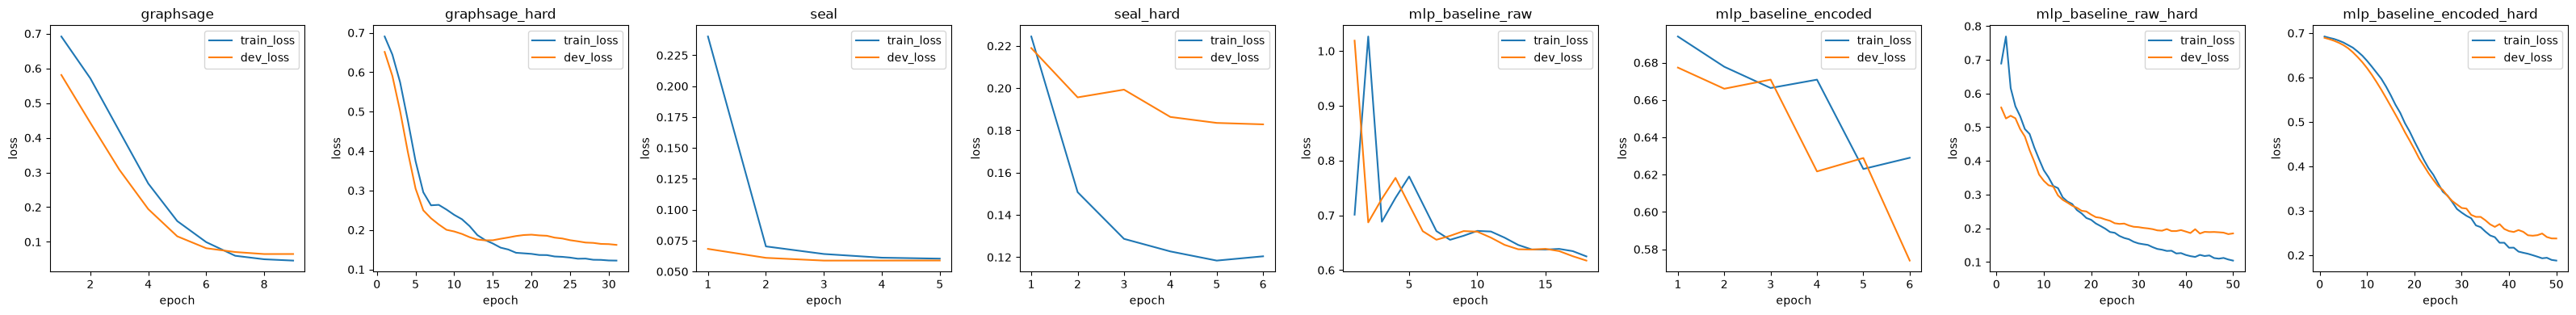

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

MODELS = ["graphsage", "graphsage_hard", "seal", "seal_hard", "mlp_baseline_raw", "mlp_baseline_encoded", "mlp_baseline_raw_hard", "mlp_baseline_encoded_hard"]


def plot_losses(model_name, ax):
    """Plots train_loss and dev_loss vs. epoch for one model's epoch_metrics.csv."""
    df = pd.read_csv(f"./results/{model_name}_epoch_metrics.csv")
    ax.plot(df["epoch"], df["train_loss"], label="train_loss")
    ax.plot(df["epoch"], df["dev_loss"], label="dev_loss")
    ax.set_title(model_name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()


fig, axes = plt.subplots(1, len(MODELS), figsize=(4 * len(MODELS), 4))
for ax, model_name in zip(axes, MODELS):
    plot_losses(model_name, ax)
plt.tight_layout()
plt.show()


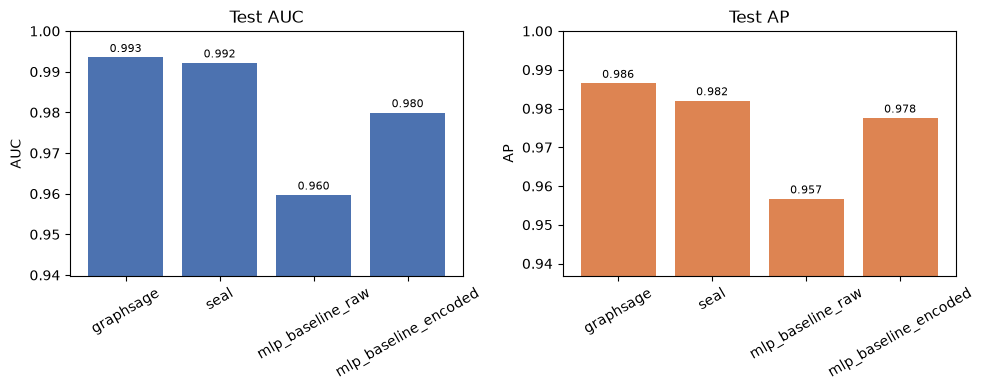

In [ ]:
eval_dfs = []
for model_name in ["graphsage", "seal", "mlp_baseline_raw", "mlp_baseline_encoded"]:
    df = pd.read_csv(f"./results/{model_name}_eval_metrics.csv")
    df["model"] = model_name
    eval_dfs.append(df)
eval_all = pd.concat(eval_dfs, ignore_index=True)
eval_dev = eval_all[eval_all["split"] == "test"]

# AUC and AP are different measurements (ranking quality vs. precision-recall
# tradeoff) that happen to share a [0, 1] range, each gets its own colour
# and independently-scaled axis on purpose, so bar height across the two
# subplots is never a valid comparison, only within one subplot.
METRIC_STYLE = {"auc": "#4C72B0", "ap": "#DD8452"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ["auc", "ap"]):
    bars = ax.bar(eval_dev["model"], eval_dev[metric], color=METRIC_STYLE[metric])
    ax.set_title(f"Test {metric.upper()}")
    ax.set_ylabel(metric.upper())
    ax.set_ylim(eval_dev[metric].min() - 0.02, 1.0)
    ax.tick_params(axis="x", rotation=30)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout()
plt.show()


## 6. Compare hard-negative results

A separate chart from section 5 above, **on purpose**. Hard negatives (2-hop, structurally plausible non-edges) are a strictly harder discrimination task than the random negatives section 5 uses, so `graphsage_hard`, `seal_hard`, and `mlp_baseline_{raw,encoded}_hard` scores are **not comparable** to section 5's numbers and shouldn't be plotted on the same axis.

Within this group, though, `mlp_baseline_{raw,encoded}_hard` vs. `graphsage_hard` and `seal_hard` is exactly the comparison that isolates whether message passing helps distinguish a real citation from a structurally plausible near-miss.

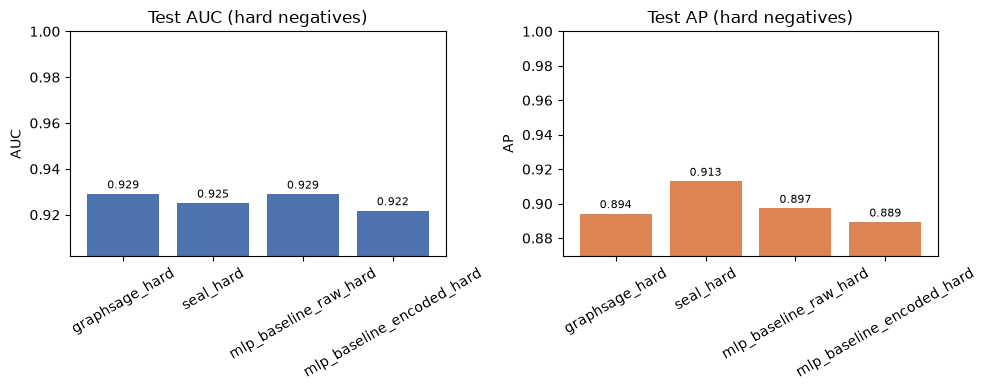

In [5]:
eval_dfs_hard = []
for model_name in ["graphsage_hard", "seal_hard", "mlp_baseline_raw_hard", "mlp_baseline_encoded_hard"]:
    df = pd.read_csv(f"./results/{model_name}_eval_metrics.csv")
    df["model"] = model_name
    eval_dfs_hard.append(df)
eval_all_hard = pd.concat(eval_dfs_hard, ignore_index=True)
eval_dev_hard = eval_all_hard[eval_all_hard["split"] == "test"]

# Same reasoning as the section 5 chart: AUC and AP are not comparable to
# each other, so each subplot gets its own colour and its own
# independently-scaled axis rather than sharing one.
METRIC_STYLE = {"auc": "#4C72B0", "ap": "#DD8452"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ["auc", "ap"]):
    bars = ax.bar(eval_dev_hard["model"], eval_dev_hard[metric], color=METRIC_STYLE[metric])
    ax.set_title(f"Test {metric.upper()} (hard negatives)")
    ax.set_ylabel(metric.upper())
    ax.set_ylim(eval_dev_hard[metric].min() - 0.02, 1.0)
    ax.tick_params(axis="x", rotation=30)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout()
plt.show()


## 7. Second-hand citation analysis

Not a model to train or evaluate. `second_hand_citation.py` looks for **closed triads** (u cites w, w cites x, u also cites x directly) where u's and w's citing-sentence text for x are unusually similar. This textual similarity is a signal that u may have picked up x through w rather than engaging with it directly (a "second-hand citation").

- Runs on the `test` split with the script's own defaults: `--max-triads 5000`, `--top-k 20`, `--min-citers 3`, device auto-detected.
- Embeds only the citing sentences actually needed for the triads under test, using SciBERT (Beltagy, Lo & Cohan, [*SciBERT: A Pretrained Language Model for Scientific Text*, EMNLP-IJCNLP 2019](https://arxiv.org/abs/1903.10676)), cached at `graphs/cache/scibert_edge_embeddings.pkl`. This is a **separate** embedding from the SPECTER2 node embeddings used in sections 1 to 6 above, and this section has nothing to do with the trained models otherwise.
- The script prints its results with `print(...)` and `to_string(...)` rather than returning a DataFrame, so the output below renders as plain text rather than a formatted table.

In [ ]:
%run ../scripts/second_hand_citation.py --max-triads 500 --top-k 500


Loading test split...
Finding closed triads (u -> w -> x, with u -> x also real)...
Found 500 closed triads
11412 distinct citing-sentence embeddings needed (11412 resolved to a real edge)
Embedding 11412 new citing sentences with allenai/scibert_scivocab_uncased...


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/228k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  442MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

[transformers] BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  442MB            

model.safetensors: downloading bytes:           |  0.00B            

Scored 219 triads (271 skipped: no background or missing text, 10 skipped: missing year, year(x) <= year(w) <= year(u) not satisfied, or publication_date shows x/w/u out of order within a shared year)

Percentile distribution: mean=0.576  median=0.581  frac >= 0.95: 0.078

Full results (219 rows, untruncated) written to /content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/results/second_hand_citation_test.csv
Percentile distribution plot written to /content/drive/MyDrive/pellegrinoscavello2425/scripts/../GNNs/results/second_hand_citation_test_percentiles.png

All 219 scored triads, ordered by percentile (u -> x, plausibly derived from w -> x):

 rank  percentile  similarity  bg_mean  n_bg            u            w            x     date_u     date_w     date_x                                                              u->x text                                                              w->x text
    1       1.000      1.0000   0.8665    28 3728c398a905 729be2eb3c56 bb472224

<Figure size 640x480 with 0 Axes>

## 8. Conclusion

Random negatives make every model look strong. Hard negatives reveal what actually matters: SPECTER2 content alone gets GraphSAGE most of the way there, and the graph structure only pays off when the task is telling a real citation apart from a structurally similar non-citation. SEAL's edge over GraphSAGE in that setting confirms local subgraph reasoning adds something neighbourhood aggregation misses.

For the project, this means hard negative evaluation should be the default, not an add-on, and SEAL is the model worth investing in if the goal is distinguishing genuine citations from plausible near misses. GraphSAGE stays useful as a cheaper baseline, not as the headline result.

The second hand citation analysis adds a second axis entirely: not whether a citation exists, but whether it was actually engaged with firsthand. A few near-verbatim matches suggest this signal is real and worth folding into the pipeline, as a feature or a filter, rather than left as a standalone check.